In [1]:
# =========================================
# [셀 1] Carry Trade Regime Engine - 환경 설정 및 기본 유틸
#
# 목적:
# - 캐리 트레이드 관련 레짐 판정을 위한 공통 유틸 정의
# - 이후 셀에서 점수화 / Pass-Fail 로직에 재사용
#
# 전제:
# - 실행 환경: VSCode + Jupyter + Python
# - 프로젝트 루트: C:\QP2
# - 이 셀은 "로직 없음", 전부 기반 도구임
#
# 주의:
# - 이 셀은 반드시 가장 먼저 실행
# - 여기서 에러 나면 이후 전부 무너짐
# =========================================

import os
import sys
import numpy as np
import pandas as pd

# -----------------------------------------
# 1) 프로젝트 루트 고정
# -----------------------------------------
# 어떤 위치에서 노트북을 열어도
# 항상 C:\QP2 기준으로 경로가 잡히게 만든다

PROJECT_ROOT = r"C:\QP2"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

# sanity check
print("📁 Current Working Directory:", os.getcwd())


# -----------------------------------------
# 2) 공통 롤링 통계 유틸
# -----------------------------------------
# 이후 모든 지표 점수화에서 재사용됨
# "셀 단위 재사용"을 전제로 여기서 정의


def rolling_zscore(
    s: pd.Series,
    window: int = 252,
    min_periods: int | None = None,
) -> pd.Series:
    """
    목적:
    - 롤링 z-score 계산
    - 캐리, 변동성, 환율 모멘텀 표준화에 사용

    주의:
    - 분모 0 방지
    - window 초반 NaN 허용
    """
    if min_periods is None:
        min_periods = max(20, window // 5)

    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std(ddof=0)

    z = (s - mean) / std.replace(0, np.nan)
    return z


def rolling_percentile_rank(
    s: pd.Series,
    window: int = 252,
    min_periods: int | None = None,
) -> pd.Series:
    """
    목적:
    - 최근 window 구간 내에서 현재 값의 백분위(0~1)
    - VIX, FX vol 같이 '수준 자체가 중요한 지표'에 사용
    """
    if min_periods is None:
        min_periods = max(20, window // 5)

    def _rank_last(x):
        last = x[-1]
        return np.nanmean(x <= last)

    return s.rolling(window, min_periods=min_periods).apply(
        _rank_last, raw=True
    )


# -----------------------------------------
# 3) 점수 변환 유틸
# -----------------------------------------
# 모든 지표는 최종적으로 0~100 점수로 통일


def clip_01(x: pd.Series) -> pd.Series:
    """0~1 범위 강제"""
    return x.clip(lower=0.0, upper=1.0)


def to_score_0_100(x01: pd.Series) -> pd.Series:
    """
    목적:
    - 0~1 스케일 → 0~100 점수
    """
    return (clip_01(x01) * 100.0).astype(float)


# -----------------------------------------
# 4) 공통 판정 유틸 (Pass / Fail)
# -----------------------------------------
# 개별 지표, 레짐 전체 모두 여기 로직 사용


def apply_pass_rule(
    score: pd.Series,
    op: str,
    threshold: float,
) -> pd.Series:
    """
    목적:
    - 점수 기반 Pass / Fail 판정

    op:
    - '>=', '>', '<=', '<', '=='
    """
    if op == ">=":
        return score >= threshold
    if op == ">":
        return score > threshold
    if op == "<=":
        return score <= threshold
    if op == "<":
        return score < threshold
    if op == "==":
        return score == threshold

    raise ValueError(f"지원하지 않는 판정 연산자: {op}")


print("✅ [셀 1] 기본 환경 및 유틸 로딩 완료")


📁 Current Working Directory: C:\QP2
✅ [셀 1] 기본 환경 및 유틸 로딩 완료


In [2]:
# =========================================
# [셀 2] Carry Trade Regime Engine - 지표 스펙(INDICATORS) 정의
#
# 목적:
# - "각 지표를 어떻게 점수화할지"와 "Pass/Fail 임계"를 한 곳에 선언
# - 이후 셀(스코어링 엔진)이 이 설정을 그대로 읽어서 계산
#
# 핵심 개념:
# - score_rule: raw → 0~100 점수 변환 규칙
# - direction: higher_better / lower_better
# - pass_rule: 점수 기반 pass/fail 판정
# - hard_fail: True면 fail 시 레짐을 즉시 Fail로 만드는 트리거
#
# 컬럼 매핑 주의:
# - col= 에 적힌 컬럼명이 df.columns에 반드시 있어야 함
# - 아직 데이터 로더를 안 만들었으면, 우선 "이름만" 맞춰두고
#   나중에 df 만들 때 이 컬럼들을 생성하면 됨
#
# 추천 초기 MVP:
# - 하드페일: (1) JPY 강세 신호, (2) FX 변동성 상승, (3) 달러 펀딩 스트레스
# =========================================

# -----------------------------------------
# 1) 점수화 규칙 템플릿 설명(주석)
# -----------------------------------------
# score_rule.type
# - "z":
#   * rolling_zscore로 표준화 후 [-z_cap, +z_cap]를 0~100으로 맵핑
#   * 모멘텀/스프레드/베이시스처럼 '상대적 수준'이 중요한 지표에 유리
#
# - "pctrank":
#   * rolling_percentile_rank로 0~1 백분위 → 0~100
#   * VIX/IV처럼 '수준'이 중요한 지표에 유리
#
# - "threshold":
#   * low/high 임계 기반 0/50/100 (간단하지만 과격함)
#
# direction
# - "higher_better": 값이 높을수록 좋은 환경(리스크온)
# - "lower_better": 값이 낮을수록 좋은 환경(리스크온)
#
# pass_rule 기준:
# - 점수(score)가 임계 이상이면 pass로 두는 게 일반적
# - 예외적으로 "너무 높은 게 나쁜" 지표도 있으니 direction으로 뒤집고 통일
# -----------------------------------------


# -----------------------------------------
# 2) 지표 스펙(초기형)
# -----------------------------------------
# NOTE:
# - 여기 스펙은 '초기 MVP'라서 보수적으로 설계
# - 실전에서는 threshold/weight는 백테스트로 튜닝해야 함
# -----------------------------------------

INDICATORS = [
    # (A) 글로벌 변동성: VIX (낮을수록 좋음)
    # - score_rule: pctrank 사용 (레벨 기반)
    # - direction: lower_better로 뒤집어 점수 높을수록 좋게 통일
    dict(
        name="VIX",
        col="vix",  # df에 vix 컬럼 필요
        score_rule=dict(type="pctrank", window=252),
        direction="lower_better",
        weight=1.0,
        pass_rule=dict(op=">=", thresh=55.0, hard_fail=False),  # 점수 55 이상이면 통과
    ),

    # (B) JPY 시그널: USDJPY 20일 수익률
    # - 해석: USDJPY↑ = JPY 약세(리스크온 성향)
    # - 따라서 higher_better
    # - 하드페일: 점수가 너무 낮으면(엔 강세) 급락 구간 가능성↑
    dict(
        name="USDJPY_MOM_20D",
        col="usdjpy_ret_20d",  # df에 USDJPY 20일 수익률
        score_rule=dict(type="z", window=252, z_cap=2.0),
        direction="higher_better",
        weight=1.2,
        pass_rule=dict(op=">=", thresh=45.0, hard_fail=True),
    ),

    # (C) FX Implied Vol (낮을수록 캐리 우호)
    # - 예: 대상국 통화 바스켓 1M IV, 혹은 대표 EM FX IV
    # - pctrank로 레벨을 평가하고 lower_better로 뒤집음
    # - 하드페일: 변동성이 올라붙으면 캐리 붕괴 리스크가 급격히 증가
    dict(
        name="FX_IV_1M",
        col="fx_iv_1m",
        score_rule=dict(type="pctrank", window=252),
        direction="lower_better",
        weight=1.3,
        pass_rule=dict(op=">=", thresh=55.0, hard_fail=True),
    ),

    # (D) Carry-to-Risk (금리차 / 변동성) 같은 합성지표 (높을수록 좋음)
    dict(
        name="CARRY_TO_RISK",
        col="carry_to_risk",
        score_rule=dict(type="z", window=252, z_cap=2.5),
        direction="higher_better",
        weight=1.0,
        pass_rule=dict(op=">=", thresh=50.0, hard_fail=False),
    ),

    # (E) 달러 펀딩 스트레스: Cross-currency basis(또는 유사 스트레스 지표)
    # - 가정: basis_usd 값이 "높을수록(덜 음수) 스트레스 낮다" => higher_better
    # - 하드페일: 달러 펀딩 스트레스는 레버리지 해소를 촉발하기 쉬움
    dict(
        name="USD_FUNDING_BASIS",
        col="basis_usd",
        score_rule=dict(type="z", window=252, z_cap=2.0),
        direction="higher_better",
        weight=1.1,
        pass_rule=dict(op=">=", thresh=45.0, hard_fail=True),
    ),

    # (F) 옵션 스큐/리스크리버설(예: 25D RR)
    # - 값이 낮아질수록(더 음수) 하방/펀딩통화 강세에 대한 보험 수요↑ 로 해석 가능
    # - 따라서 higher_better (덜 음수/양수면 더 좋다)
    dict(
        name="FX_RISK_REVERSAL",
        col="fx_rr_25d",
        score_rule=dict(type="z", window=252, z_cap=2.0),
        direction="higher_better",
        weight=0.8,
        pass_rule=dict(op=">=", thresh=45.0, hard_fail=False),
    ),
]

# -----------------------------------------
# 3) 최종 레짐 판정 기본 파라미터 (초기값)
# -----------------------------------------
# final_pass_score_thresh:
# - 가중평균 최종 점수 기준 Pass 임계값
#
# require_all_pass:
# - True: 모든 지표 pass여야 레짐 pass (너무 보수적일 수 있음)
# - False: 최종 점수 기준 + hard_fail만 반영 (실전형)
#
# hard_fail_overrides:
# - True: hard_fail 지표 하나라도 fail이면 레짐 무조건 Fail
# -----------------------------------------

REGIME_PARAMS = dict(
    final_pass_score_thresh=60.0,
    require_all_pass=False,
    hard_fail_overrides=True,
)

print("✅ [셀 2] INDICATORS 및 REGIME_PARAMS 정의 완료")
print(" - indicators:", [x["name"] for x in INDICATORS])
print(" - regime_params:", REGIME_PARAMS)


✅ [셀 2] INDICATORS 및 REGIME_PARAMS 정의 완료
 - indicators: ['VIX', 'USDJPY_MOM_20D', 'FX_IV_1M', 'CARRY_TO_RISK', 'USD_FUNDING_BASIS', 'FX_RISK_REVERSAL']
 - regime_params: {'final_pass_score_thresh': 60.0, 'require_all_pass': False, 'hard_fail_overrides': True}


In [4]:
# =========================================
# [셀 3] Carry Trade Regime Engine - 스코어링 엔진(점수화 + Pass/Fail) 본체
#
# 목적:
# - [셀 2]에서 정의한 INDICATORS / REGIME_PARAMS를 받아
#   1) 각 지표 raw → score(0~100) 산출
#   2) 각 지표 pass/fail 산출
#   3) 가중평균으로 REGIME score 산출
#   4) REGIME pass/fail 산출 (hard_fail 옵션 반영)
#
# 출력:
# - 지표별 raw / score / pass
# - REGIME__score / REGIME__pass
# =========================================

import numpy as np
import pandas as pd


# -----------------------------------------
# 1) raw → score 계산
# -----------------------------------------
def compute_indicator_score(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    col = spec["col"]
    name = spec["name"]

    if col not in df.columns:
        raise KeyError(
            f"df에 '{col}' 컬럼이 없소. "
            f"INDICATORS에서 col 매핑을 확인하시오. (indicator={name})"
        )

    s = df[col].astype(float)
    rule = spec["score_rule"]
    rtype = rule["type"].lower()

    if rtype == "z":
        window = int(rule.get("window", 252))
        z_cap = float(rule.get("z_cap", 2.0))
        z = rolling_zscore(s, window=window)
        x01 = (z.clip(-z_cap, z_cap) + z_cap) / (2.0 * z_cap)

    elif rtype == "pctrank":
        window = int(rule.get("window", 252))
        x01 = rolling_percentile_rank(s, window=window)

    elif rtype == "threshold":
        low = rule.get("low", None)
        high = rule.get("high", None)
        if low is None or high is None:
            raise ValueError(f"threshold rule에 low/high 필요 (indicator={name})")
        x01 = np.where(s <= low, 0.0, np.where(s >= high, 1.0, 0.5))
        x01 = pd.Series(x01, index=s.index, dtype=float)

    else:
        raise ValueError(f"알 수 없는 score_rule type: {rtype}")

    direction = spec.get("direction", "higher_better").lower()
    if direction == "lower_better":
        x01 = 1.0 - x01
    elif direction != "higher_better":
        raise ValueError(f"direction 오류 (indicator={name})")

    score = to_score_0_100(pd.Series(x01, index=s.index))

    out = pd.DataFrame(index=df.index)
    out[f"{name}__raw"] = s
    out[f"{name}__score"] = score
    return out


# -----------------------------------------
# 2) score → pass/fail
# -----------------------------------------
def compute_indicator_pass(score: pd.Series, pass_rule: dict) -> pd.Series:
    op = pass_rule.get("op", ">=")
    thresh = float(pass_rule.get("thresh", 50.0))
    return apply_pass_rule(score, op=op, threshold=thresh).astype("boolean")


# -----------------------------------------
# 3) 전체 레짐 엔진
# -----------------------------------------
def run_regime_scoring(
    df: pd.DataFrame,
    indicators: list,
    final_pass_score_thresh: float = 60.0,
    require_all_pass: bool = False,
    hard_fail_overrides: bool = True,
) -> pd.DataFrame:

    if isinstance(df.index, pd.DatetimeIndex):
        df = df.sort_index()

    blocks = []
    pass_cols = []
    score_cols = []
    weights = []
    hard_fail_cols = []

    for spec in indicators:
        name = spec["name"]
        w = float(spec.get("weight", 1.0))
        pr = spec.get("pass_rule", dict(op=">=", thresh=50.0, hard_fail=False))

        b = compute_indicator_score(df, spec)
        blocks.append(b)

        sc = f"{name}__score"
        score_cols.append(sc)
        weights.append(w)

        p = compute_indicator_pass(b[sc], pr)
        pcol = f"{name}__pass"
        blocks.append(pd.DataFrame({pcol: p}, index=df.index))
        pass_cols.append(pcol)

        if pr.get("hard_fail", False):
            hard_fail_cols.append(pcol)

    res = pd.concat(blocks, axis=1)

    w = np.array(weights, dtype=float)
    w = w / np.nansum(w)
    score_mat = res[score_cols].to_numpy(dtype=float)
    res["REGIME__score"] = np.nansum(score_mat * w.reshape(1, -1), axis=1)

    if require_all_pass:
        base_pass = res[pass_cols].all(axis=1)
    else:
        base_pass = res["REGIME__score"] >= final_pass_score_thresh

    res["REGIME__pass_base"] = base_pass.astype("boolean")

    if hard_fail_overrides and hard_fail_cols:
        hard_ok = res[hard_fail_cols].all(axis=1)
        res["REGIME__pass"] = (res["REGIME__pass_base"] & hard_ok).astype("boolean")
    else:
        res["REGIME__pass"] = res["REGIME__pass_base"].astype("boolean")

    return res


# -----------------------------------------
# 4) 최신 상태 요약 (pass → is_pass로 명명)
# -----------------------------------------
def summarize_latest(res: pd.DataFrame, indicators: list) -> pd.DataFrame:
    if res.empty:
        return pd.DataFrame(columns=["indicator", "raw", "score", "is_pass", "weight"])

    last = res.dropna(subset=["REGIME__score"]).iloc[-1:]

    rows = []
    for spec in indicators:
        nm = spec["name"]
        rows.append(
            {
                "indicator": nm,
                "raw": float(last[f"{nm}__raw"].iloc[0]),
                "score": float(last[f"{nm}__score"].iloc[0]),
                "is_pass": bool(last[f"{nm}__pass"].iloc[0]),
                "weight": float(spec.get("weight", 1.0)),
            }
        )

    rows.append(
        {
            "indicator": "REGIME",
            "raw": np.nan,
            "score": float(last["REGIME__score"].iloc[0]),
            "is_pass": bool(last["REGIME__pass"].iloc[0]),
            "weight": np.nan,
        }
    )

    return pd.DataFrame(rows)


print("✅ [셀 3] 수정 완료 — pass 예약어 충돌 해결")


✅ [셀 3] 수정 완료 — pass 예약어 충돌 해결


In [5]:
# =========================================
# [셀 4] Carry Trade Regime Engine - 데이터 준비(로딩/생성) + 첫 실행(MVP)
#
# 목적:
# - 레짐 엔진(run_regime_scoring)을 실제로 "한 번" 돌려서
#   1) 컬럼 매핑이 맞는지
#   2) NaN 구간이 어디인지
#   3) 레짐 점수/Pass가 제대로 생성되는지
#   를 즉시 확인
#
# 전략:
# - (A) 기존 데이터가 있으면: 그 데이터를 df로 맞추기
# - (B) 아직 없으면: 더미(df_dummy)로 엔진 검증 후, 다음 셀에서 실데이터로 교체
#
# 주의:
# - 이 셀은 "실데이터 연결 전"에도 반드시 통과해야 함
# - 여기서 통과하면, 이후는 데이터 소스만 바꿔 끼우면 됨
# =========================================

import numpy as np
import pandas as pd


# -----------------------------------------
# 1) (B) 더미 데이터로 먼저 검증
# -----------------------------------------
# 아직 vix/usdjpy/fx_iv/basis 등 실제 시계열을 붙이기 전이라면
# 아래 더미 데이터로 엔진이 정상 작동하는지부터 확인하시오.
#
# 더미 생성 원칙:
# - 완전 랜덤이 아니라 "레짐 전환"처럼 보이게
#   특정 구간에서 VIX↑, FX vol↑, USDJPY ret↓(엔 강세) 같은 패턴을 인위적으로 넣음
# -----------------------------------------

def make_dummy_regime_df(
    start="2018-01-01",
    end="2024-12-31",
    seed=7,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    idx = pd.date_range(start, end, freq="B")  # 영업일

    n = len(idx)

    # 기본 노이즈
    vix = 18 + rng.normal(0, 2.0, n)
    usdjpy_ret_20d = rng.normal(0.0, 0.02, n)
    fx_iv_1m = 9 + rng.normal(0, 1.0, n)
    carry_to_risk = 0.8 + rng.normal(0, 0.15, n)
    basis_usd = -0.15 + rng.normal(0, 0.05, n)
    fx_rr_25d = -0.5 + rng.normal(0, 0.2, n)

    # "스트레스 구간"을 3번 넣음 (캐리 청산 시뮬레이션)
    stress_windows = [
        ("2019-08-01", "2019-09-30"),
        ("2020-03-01", "2020-05-15"),
        ("2022-06-01", "2022-07-31"),
    ]

    for a, b in stress_windows:
        m = (idx >= a) & (idx <= b)
        vix[m] += 12 + rng.normal(0, 2.0, m.sum())             # VIX 급등
        fx_iv_1m[m] += 6 + rng.normal(0, 1.0, m.sum())         # FX IV 급등
        usdjpy_ret_20d[m] -= 0.06 + rng.normal(0, 0.02, m.sum())  # USDJPY 하락(엔 강세)
        carry_to_risk[m] -= 0.35 + rng.normal(0, 0.05, m.sum())   # 캐리 매력 급락
        basis_usd[m] -= 0.15 + rng.normal(0, 0.03, m.sum())       # 베이시스 악화(더 음수)
        fx_rr_25d[m] -= 0.4 + rng.normal(0, 0.1, m.sum())         # 스큐 악화(더 음수)

    df = pd.DataFrame(
        {
            "vix": vix,
            "usdjpy_ret_20d": usdjpy_ret_20d,
            "fx_iv_1m": fx_iv_1m,
            "carry_to_risk": carry_to_risk,
            "basis_usd": basis_usd,
            "fx_rr_25d": fx_rr_25d,
        },
        index=idx,
    )

    # 현실성 최소 보정(음수 불가한 지표 등)
    df["vix"] = df["vix"].clip(lower=8)
    df["fx_iv_1m"] = df["fx_iv_1m"].clip(lower=3)
    return df


df = make_dummy_regime_df()

print("✅ 더미 df 생성 완료")
print(" - rows:", len(df), "| cols:", df.shape[1])
display(df.head())


# -----------------------------------------
# 2) 레짐 엔진 실행
# -----------------------------------------
res = run_regime_scoring(df, INDICATORS, **REGIME_PARAMS)

print("✅ 레짐 산출 완료")
display(res[["REGIME__score", "REGIME__pass"]].tail(10))


# -----------------------------------------
# 3) 최신 상태 요약(지표별 점수/Pass)
# -----------------------------------------
summary = summarize_latest(res, INDICATORS)
display(summary)


# -----------------------------------------
# 4) (옵션) 레짐 Pass 비율 / 스트레스 구간 확인
# -----------------------------------------
pass_rate = float(res["REGIME__pass"].mean())
print(f"📌 REGIME Pass Rate: {pass_rate:.2%}")

# 레짐 Fail이 몰리는 구간이 있는지 빠르게 보기
fail_streak = (res["REGIME__pass"] == False).astype(int)  # boolean → int
print("📌 최근 60영업일 Fail 개수:", int(fail_streak.tail(60).sum()))

print("✅ [셀 4] 완료 — 더미 데이터로 엔진 작동 검증 끝")
print(" - 다음 셀에서: 실데이터를 불러와 df 컬럼만 동일하게 맞추면 바로 적용 가능")


✅ 더미 df 생성 완료
 - rows: 1827 | cols: 6


,vix,usdjpy_ret_20d,fx_iv_1m,carry_to_risk,basis_usd,fx_rr_25d
2018-01-01,18.002460,0.000283,8.377078,0.939140,-0.170227,-0.518937
2018-01-02,18.597491,-0.019554,8.096029,0.923099,-0.143173,-0.309078
2018-01-03,17.451724,0.011362,10.451762,0.983439,-0.182227,-0.647519
2018-01-04,16.218816,-0.040838,8.117431,1.068089,-0.185540,-0.454585
2018-01-05,17.090658,-0.008657,11.073636,0.659100,-0.158639,-0.732795


✅ 레짐 산출 완료


,REGIME__score,REGIME__pass
2024-12-18,40.176753,False
2024-12-19,40.499600,False
2024-12-20,59.349738,False
2024-12-23,49.116274,False
2024-12-24,42.599249,False
2024-12-25,37.585339,False
2024-12-26,32.673028,False
2024-12-27,45.769643,False
2024-12-30,61.720835,False
2024-12-31,64.931468,False


,indicator,raw,score,is_pass,weight
0,VIX,18.353009,39.285714,False,1.0
1,USDJPY_MOM_20D,0.028347,88.559235,True,1.2
2,FX_IV_1M,8.030040,80.158730,True,1.3
3,CARRY_TO_RISK,1.072433,91.529790,True,1.0
4,USD_FUNDING_BASIS,-0.195789,28.806775,False,1.1
5,FX_RISK_REVERSAL,-0.472218,53.226260,True,0.8
6,REGIME,NaN,64.931468,False,NaN


📌 REGIME Pass Rate: 14.94%
📌 최근 60영업일 Fail 개수: 57
✅ [셀 4] 완료 — 더미 데이터로 엔진 작동 검증 끝
 - 다음 셀에서: 실데이터를 불러와 df 컬럼만 동일하게 맞추면 바로 적용 가능


In [8]:
# =========================================
# [셀 5] Carry Trade Regime Engine - "실데이터 자동 생성" (오류 수정본)
#
# 에러 요약:
# - ValueError: If using all scalar values, you must pass an index
# - 원인: yfinance 응답에서 'Close'를 뽑는 과정이 상황에 따라
#         Series가 아니라 (1) DataFrame(멀티인덱스) 또는 (2) 잘못된 형태로 들어와
#         pd.DataFrame({"vix": vix_close})에서 스칼라로 취급된 것.
#
# 해결:
# - yfinance 결과를 "무조건 Series(DatetimeIndex 포함)"로 정규화하는 함수 추가
# - DataFrame이면 1개 컬럼으로 축소, MultiIndex면 Close 레벨을 안전하게 추출
# - 저장은 항상 to_frame("colname")로 처리 (인덱스 보장)
#
# 결과:
# - vix.csv / usdjpy.csv 자동 생성 + proxy 지표 생성 + 레짐 산출
# =========================================

import os
import numpy as np
import pandas as pd

# -----------------------------------------
# 1) 경로 설정
# -----------------------------------------
DATA_DIR_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_DIR_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(DATA_DIR_RAW, exist_ok=True)
os.makedirs(DATA_DIR_PROCESSED, exist_ok=True)

print("📁 RAW:", DATA_DIR_RAW)
print("📁 PROCESSED:", DATA_DIR_PROCESSED)


# -----------------------------------------
# 2) 공통 저장/로드 유틸
# -----------------------------------------
def _save_csv(df: pd.DataFrame, path: str) -> None:
    df = df.copy()
    df.to_csv(path, index=True)

def _load_csv(path: str) -> pd.DataFrame:
    tmp = pd.read_csv(path)
    if "date" in tmp.columns:
        tmp["date"] = pd.to_datetime(tmp["date"])
        tmp = tmp.set_index("date")
    elif "Date" in tmp.columns:
        tmp["Date"] = pd.to_datetime(tmp["Date"])
        tmp = tmp.set_index("Date")
    else:
        tmp.iloc[:, 0] = pd.to_datetime(tmp.iloc[:, 0])
        tmp = tmp.set_index(tmp.columns[0])

    tmp = tmp.sort_index()
    return tmp


# -----------------------------------------
# 3) yfinance 결과를 "무조건 Series"로 정규화
# -----------------------------------------
def _ensure_series(x, name: str) -> pd.Series:
    """
    목적:
    - yfinance 결과에서 뽑아낸 값이
      Series / DataFrame / 이상한 형태로 섞여 들어와도
      최종적으로 DatetimeIndex 가진 Series로 강제 변환

    규칙:
    - Series면 그대로
    - DataFrame이면:
      * 컬럼 1개면 그 컬럼
      * 멀티인덱스면 최대한 1개로 축소 후 첫 컬럼
    - 그 외는 에러 (스칼라/문자열 등)
    """
    if isinstance(x, pd.Series):
        s = x.copy()
    elif isinstance(x, pd.DataFrame):
        df = x.copy()

        # 멀티인덱스 컬럼이면 우선 평탄화 시도
        if isinstance(df.columns, pd.MultiIndex):
            # (예) columns: ('Close','^VIX') 형태일 수 있음
            # Close 레벨을 뽑는 건 호출부에서 했으니, 여기선 1개 컬럼으로 축소
            if df.shape[1] == 1:
                s = df.iloc[:, 0]
            else:
                # 여러 컬럼이면 첫 컬럼을 사용 (보수적)
                s = df.iloc[:, 0]
        else:
            if df.shape[1] == 1:
                s = df.iloc[:, 0]
            else:
                # 여러 컬럼이면 첫 컬럼 사용
                s = df.iloc[:, 0]
    else:
        raise ValueError(f"{name}: Series/DataFrame이 아닌 값이 들어왔소. type={type(x)}")

    # 인덱스가 DatetimeIndex인지 보정
    if not isinstance(s.index, pd.DatetimeIndex):
        try:
            s.index = pd.to_datetime(s.index)
        except Exception as e:
            raise ValueError(f"{name}: 인덱스를 datetime으로 변환 못 했소.") from e

    s = s.sort_index()
    s = s.astype(float)
    s.name = name
    return s


# -----------------------------------------
# 4) yfinance 다운로드 (VIX, USDJPY)
# -----------------------------------------
def _download_yf_close(ticker: str, start: str = "2005-01-01") -> pd.Series:
    """
    목적:
    - yfinance로 ticker의 Close(또는 Adj Close)를 받아 Series로 반환
    - 반환값은 DatetimeIndex 가진 Series 보장
    """
    try:
        import yfinance as yf
    except Exception as e:
        raise RuntimeError("yfinance import 실패. (pip install yfinance 필요)") from e

    px = yf.download(ticker, start=start, progress=False, auto_adjust=False)

    if px is None or getattr(px, "empty", True):
        raise RuntimeError(f"yfinance 다운로드 실패: {ticker} (응답이 비었소)")

    # 케이스 A: 일반 DataFrame (Open/High/Low/Close...)
    # 케이스 B: 멀티인덱스 컬럼 (level에 Close가 있고, 다른 level에 ticker)
    close_obj = None

    if isinstance(px, pd.DataFrame) and ("Close" in px.columns):
        close_obj = px["Close"]
    elif isinstance(px, pd.DataFrame) and ("Adj Close" in px.columns):
        close_obj = px["Adj Close"]
    else:
        # 멀티인덱스 가능성 처리
        if isinstance(px, pd.DataFrame) and isinstance(px.columns, pd.MultiIndex):
            # level 중 'Close'가 있으면 xs로 뽑음
            if "Close" in px.columns.get_level_values(0):
                close_obj = px.xs("Close", axis=1, level=0, drop_level=True)
            elif "Adj Close" in px.columns.get_level_values(0):
                close_obj = px.xs("Adj Close", axis=1, level=0, drop_level=True)

    if close_obj is None:
        raise RuntimeError(f"{ticker}에서 Close/Adj Close를 찾지 못했소. columns={px.columns}")

    # 최종 Series로 정규화
    s = _ensure_series(close_obj, name=f"{ticker}_close")
    return s


def ensure_vix_csv(path: str) -> pd.DataFrame:
    """
    목적:
    - vix.csv가 있으면 로드
    - 없으면 ^VIX로 생성 후 저장
    """
    if os.path.exists(path):
        df = _load_csv(path)
        if "vix" in df.columns:
            return df[["vix"]]

    vix_close = _download_yf_close("^VIX", start="2005-01-01")
    vix = vix_close.rename("vix")

    # to_frame으로 인덱스 강제(이번 에러 재발 방지)
    df = vix.to_frame()
    _save_csv(df, path)
    print("✅ 생성:", path)
    return df


def ensure_usdjpy_csv(path: str) -> pd.DataFrame:
    """
    목적:
    - usdjpy.csv가 있으면 로드
    - 없으면 JPY=X로 생성 후 저장
    """
    if os.path.exists(path):
        df = _load_csv(path)
        if ("usdjpy" in df.columns) and ("usdjpy_ret_20d" in df.columns):
            return df[["usdjpy", "usdjpy_ret_20d"]]
        if "usdjpy" in df.columns:
            df["usdjpy_ret_20d"] = df["usdjpy"].pct_change(20)
            _save_csv(df[["usdjpy", "usdjpy_ret_20d"]], path)
            return df[["usdjpy", "usdjpy_ret_20d"]]

    usdjpy_close = _download_yf_close("JPY=X", start="2005-01-01")
    usdjpy = usdjpy_close.rename("usdjpy")

    df = usdjpy.to_frame()
    df["usdjpy_ret_20d"] = df["usdjpy"].pct_change(20)

    _save_csv(df[["usdjpy", "usdjpy_ret_20d"]], path)
    print("✅ 생성:", path)
    return df[["usdjpy", "usdjpy_ret_20d"]]


# -----------------------------------------
# 5) Proxy 생성 (fx_iv_1m / basis_usd / fx_rr_25d / carry_to_risk)
# -----------------------------------------
def make_fx_iv_proxy_from_usdjpy(usdjpy_level: pd.Series) -> pd.Series:
    """
    목적:
    - implied vol이 없을 때, USDJPY 20일 실현변동성(연율화)으로 대체
    - 단위는 % 흉내를 위해 *100
    """
    ret1d = usdjpy_level.pct_change(1)
    rv20 = ret1d.rolling(20, min_periods=20).std(ddof=0) * np.sqrt(252)
    fx_iv = (rv20 * 100.0).rename("fx_iv_1m")
    return fx_iv


def make_neutral_proxy(index: pd.DatetimeIndex, base: float = 0.0, noise_scale: float = 1e-4, seed: int = 7) -> pd.Series:
    """
    목적:
    - basis/RR 등 구하기 어려운 지표를 중립값 근처로 임시 생성
    - 하드페일 지표가 NaN 때문에 전부 Fail되는 것을 방지
    """
    rng = np.random.default_rng(seed)
    x = base + rng.normal(0.0, noise_scale, len(index))
    return pd.Series(x, index=index)


def build_real_df_with_proxies() -> pd.DataFrame:
    vix_path = os.path.join(DATA_DIR_PROCESSED, "vix.csv")
    usdjpy_path = os.path.join(DATA_DIR_PROCESSED, "usdjpy.csv")

    vix_df = ensure_vix_csv(vix_path)              # vix
    uj_df = ensure_usdjpy_csv(usdjpy_path)         # usdjpy, usdjpy_ret_20d

    df = vix_df.join(uj_df, how="outer")

    # fx_iv_1m proxy
    df["fx_iv_1m"] = make_fx_iv_proxy_from_usdjpy(df["usdjpy"])

    # basis / rr neutral proxy
    df["basis_usd"] = make_neutral_proxy(df.index, base=0.0, noise_scale=1e-4, seed=11)
    df["fx_rr_25d"] = make_neutral_proxy(df.index, base=0.0, noise_scale=1e-4, seed=13)

    # carry_to_risk MVP
    df["carry_to_risk"] = 1.0 / df["fx_iv_1m"].replace(0, np.nan)

    # 정리
    df = df.sort_index()
    df = df.dropna(
        subset=["vix", "usdjpy_ret_20d", "fx_iv_1m", "carry_to_risk", "basis_usd", "fx_rr_25d"],
        how="any",
    )

    return df


# -----------------------------------------
# 6) INDICATORS 컬럼 체크
# -----------------------------------------
def check_required_columns(df: pd.DataFrame, indicators: list) -> None:
    missing = []
    for spec in indicators:
        c = spec["col"]
        if c not in df.columns:
            missing.append(c)
    if missing:
        raise KeyError(
            "df에 필요한 컬럼이 부족하오.\n"
            f"- missing: {missing}\n"
            f"- df.columns: {list(df.columns)}"
        )


# -----------------------------------------
# 7) 실행: 실데이터 df 생성 -> 레짐 산출
# -----------------------------------------
df_real = build_real_df_with_proxies()
check_required_columns(df_real, INDICATORS)

print("✅ df_real 준비 완료")
print(" - rows:", len(df_real), "| cols:", df_real.shape[1])
display(df_real.tail(5))

res_real = run_regime_scoring(df_real, INDICATORS, **REGIME_PARAMS)

print("✅ 실데이터(＋proxy) 기반 레짐 산출 완료")
display(res_real[["REGIME__score", "REGIME__pass"]].tail(10))

summary_real = summarize_latest(res_real, INDICATORS)
display(summary_real)

print("✅ [셀 5] 완료 — 다음 단계: fx_iv_1m / basis_usd / fx_rr_25d를 '진짜 정의 데이터'로 교체")


📁 RAW: C:\QP2\data\raw
📁 PROCESSED: C:\QP2\data\processed
✅ 생성: C:\QP2\data\processed\vix.csv
✅ 생성: C:\QP2\data\processed\usdjpy.csv
✅ df_real 준비 완료
 - rows: 4984 | cols: 7


,vix,usdjpy,usdjpy_ret_20d,fx_iv_1m,basis_usd,fx_rr_25d,carry_to_risk
Date,,,,,,,
2026-01-21,16.90,158.162003,0.003082,6.039814,-0.000109,-0.000096,0.165568
2026-01-22,15.64,158.455994,0.010065,5.752900,0.000126,-0.000125,0.173825
2026-01-23,16.09,158.501007,0.014887,5.462610,0.000112,0.000063,0.183063
2026-01-26,16.15,155.166000,-0.005920,9.315940,0.000162,0.000089,0.107343
2026-01-27,16.35,154.335999,-0.013594,9.420732,0.000230,-0.000034,0.106149


✅ 실데이터(＋proxy) 기반 레짐 산출 완료


,REGIME__score,REGIME__pass
Date,,
2026-01-13,70.009362,True
2026-01-14,57.861990,False
2026-01-15,64.748292,True
2026-01-16,62.925932,True
2026-01-20,46.984268,False
2026-01-21,56.253581,False
2026-01-22,72.160889,True
2026-01-23,77.858754,True
2026-01-26,54.949396,False


,indicator,raw,score,is_pass,weight
0,VIX,16.350000,62.301587,True,1.0
1,USDJPY_MOM_20D,-0.013594,29.020152,False,1.2
2,FX_IV_1M,9.420732,36.111111,False,1.3
3,CARRY_TO_RISK,0.106149,39.137308,False,1.0
4,USD_FUNDING_BASIS,0.000230,99.690922,True,1.1
5,FX_RISK_REVERSAL,-0.000034,40.631990,False,0.8
6,REGIME,NaN,50.839551,False,NaN


✅ [셀 5] 완료 — 다음 단계: fx_iv_1m / basis_usd / fx_rr_25d를 '진짜 정의 데이터'로 교체


In [9]:
# =========================================
# [셀 6] Carry Trade Regime Engine - "투자 대상국 주가" 붙이기 + 예측 규칙(신호) 생성
#
# 목적:
# - 레짐(REGIME__pass)을 '리스크 온/오프 게이트'로 사용해
#   대상국(예: 미국) 주가(또는 ETF) 포지션 신호를 만든다.
#
# 핵심 출력:
# - df_sig: (타겟 가격, 타겟 수익률, 레짐 점수/패스, 포지션 시그널, 전략 수익률)
#
# 설계(최소 MVP):
# - signal = 1 (롱)  if REGIME__pass == True
# - signal = 0 (현금) if REGIME__pass == False
# - 다음 날 체결을 가정: signal은 1일 shift해서 적용 (룩어헤드 방지)
#
# 타겟:
# - 기본은 S&P500 ETF (SPY)
# - 필요하면 대상국 ETF로 교체 가능 (예: EWJ, EEM, EWA 등)
#
# 주의:
# - yfinance 실패 가능
# - 이 셀에서 생성되는 성과는 'proxy 지표' 포함이므로 참고용
# - 다음 단계에서 지표를 진짜 정의 데이터로 바꾸면 의미가 살아남
# =========================================

import numpy as np
import pandas as pd


# -----------------------------------------
# 1) 타겟 자산 설정
# -----------------------------------------
TARGET_TICKER = "SPY"         # 미국 주식(대상국) 예시
START_DATE = "2005-01-01"     # df_real이 2005부터 생성되므로 맞춤


# -----------------------------------------
# 2) 타겟 가격 다운로드/캐시(로컬 저장)
# -----------------------------------------
TARGET_PATH = os.path.join(DATA_DIR_PROCESSED, f"target_{TARGET_TICKER}.csv")

def ensure_target_csv(path: str, ticker: str, start: str = "2005-01-01") -> pd.DataFrame:
    """
    목적:
    - target_{ticker}.csv가 있으면 로드
    - 없으면 yfinance로 생성 후 저장
    """
    if os.path.exists(path):
        df = _load_csv(path)
        # 우리가 저장할 때는 'close' 혹은 'target'로 저장할 수 있으니 유연하게 처리
        if "target" in df.columns:
            return df[["target"]]
        if "close" in df.columns:
            return df.rename(columns={"close": "target"})[["target"]]
        # 첫 컬럼을 타겟으로 가정
        return df.iloc[:, [0]].rename(columns={df.columns[0]: "target"})

    s = _download_yf_close(ticker, start=start)  # name: "{ticker}_close"
    df = s.rename("target").to_frame()
    _save_csv(df, path)
    print("✅ 생성:", path)
    return df


target_df = ensure_target_csv(TARGET_PATH, TARGET_TICKER, start=START_DATE)
print("✅ 타겟 로드 완료:", TARGET_TICKER, "| rows:", len(target_df))
display(target_df.tail(5))


# -----------------------------------------
# 3) 레짐 결과(res_real)와 타겟 병합
# -----------------------------------------
# res_real은 df_real의 인덱스 기반으로 이미 계산되어 있음(셀5에서 성공)
# target_df와 날짜를 맞춰 inner join (공통영업일)
df_sig = (
    target_df.join(res_real[["REGIME__score", "REGIME__pass"]], how="inner")
    .sort_index()
)

# 타겟 수익률(1일)
df_sig["target_ret_1d"] = df_sig["target"].pct_change(1)

print("✅ 병합 완료 | rows:", len(df_sig), "| start:", df_sig.index.min(), "| end:", df_sig.index.max())
display(df_sig.tail(5))


# -----------------------------------------
# 4) 포지션 신호 생성(룩어헤드 방지)
# -----------------------------------------
# 오늘 레짐 판정(REGIME__pass)을 보고 -> 내일 장 시작에 반영한다고 가정
# 그래서 1일 shift하여 적용
df_sig["signal_raw"] = df_sig["REGIME__pass"].astype(int)
df_sig["signal"] = df_sig["signal_raw"].shift(1)

# 초기 NaN은 0으로(포지션 없음)
df_sig["signal"] = df_sig["signal"].fillna(0).astype(int)

# 전략 수익률: 포지션 * 타겟 수익률
df_sig["strategy_ret_1d"] = df_sig["signal"] * df_sig["target_ret_1d"]

print("✅ 시그널 생성 완료")
display(df_sig[["target", "REGIME__score", "REGIME__pass", "signal", "target_ret_1d", "strategy_ret_1d"]].tail(10))


# -----------------------------------------
# 5) 간단 성과 요약(누적수익, 승률 등)
# -----------------------------------------
# 누적수익(단순 누적곱)
df_sig["target_nav"] = (1.0 + df_sig["target_ret_1d"].fillna(0)).cumprod()
df_sig["strategy_nav"] = (1.0 + df_sig["strategy_ret_1d"].fillna(0)).cumprod()

# 요약 통계
total_days = df_sig["strategy_ret_1d"].dropna().shape[0]
active_days = int(df_sig["signal"].sum())
pass_rate = float(df_sig["REGIME__pass"].mean())

# 전략의 일간 평균/표준편차(대략적인 샤프 흉내)
mu = float(df_sig["strategy_ret_1d"].mean())
sd = float(df_sig["strategy_ret_1d"].std(ddof=0))
sharpe = (mu / sd * np.sqrt(252)) if (sd and not np.isnan(sd)) else np.nan

summary_stats = pd.DataFrame(
    [
        {"metric": "기간(영업일)", "value": total_days},
        {"metric": "레짐 Pass 비율", "value": pass_rate},
        {"metric": "포지션 보유일수(signal=1)", "value": active_days},
        {"metric": "전략 일간 평균수익", "value": mu},
        {"metric": "전략 일간 변동성", "value": sd},
        {"metric": "전략 샤프(대략)", "value": sharpe},
        {"metric": "타겟 누적(NAV)", "value": float(df_sig["target_nav"].iloc[-1])},
        {"metric": "전략 누적(NAV)", "value": float(df_sig["strategy_nav"].iloc[-1])},
    ]
)

display(summary_stats)

print("✅ [셀 6] 완료 — 다음 셀에서 그래프(타겟 vs 전략 NAV)와 드로다운까지 그리겠소.")


✅ 생성: C:\QP2\data\processed\target_SPY.csv
✅ 타겟 로드 완료: SPY | rows: 5300


,target
Date,
2026-01-21,685.400024
2026-01-22,688.979980
2026-01-23,689.229980
2026-01-26,692.729980
2026-01-27,695.489990


✅ 병합 완료 | rows: 4984 | start: 2005-01-31 00:00:00 | end: 2026-01-27 00:00:00


,target,REGIME__score,REGIME__pass,target_ret_1d
Date,,,,
2026-01-21,685.400024,56.253581,False,0.011541
2026-01-22,688.979980,72.160889,True,0.005223
2026-01-23,689.229980,77.858754,True,0.000363
2026-01-26,692.729980,54.949396,False,0.005078
2026-01-27,695.489990,50.839551,False,0.003984


✅ 시그널 생성 완료


,target,REGIME__score,REGIME__pass,signal,target_ret_1d,strategy_ret_1d
Date,,,,,,
2026-01-13,693.770020,70.009362,True,1,-0.001999,-0.001999
2026-01-14,690.359985,57.861990,False,1,-0.004915,-0.004915
2026-01-15,692.239990,64.748292,True,0,0.002723,0.000000
2026-01-16,691.659973,62.925932,True,1,-0.000838,-0.000838
2026-01-20,677.580017,46.984268,False,1,-0.020357,-0.020357
2026-01-21,685.400024,56.253581,False,0,0.011541,0.000000
2026-01-22,688.979980,72.160889,True,0,0.005223,0.000000
2026-01-23,689.229980,77.858754,True,1,0.000363,0.000363
2026-01-26,692.729980,54.949396,False,1,0.005078,0.005078


,metric,value
0,기간(영업일),4983.000000
1,레짐 Pass 비율,0.147673
2,포지션 보유일수(signal=1),736.000000
3,전략 일간 평균수익,0.000064
4,전략 일간 변동성,0.002891
5,전략 샤프(대략),0.350028
6,타겟 누적(NAV),5.886002
7,전략 누적(NAV),1.345482


✅ [셀 6] 완료 — 다음 셀에서 그래프(타겟 vs 전략 NAV)와 드로다운까지 그리겠소.


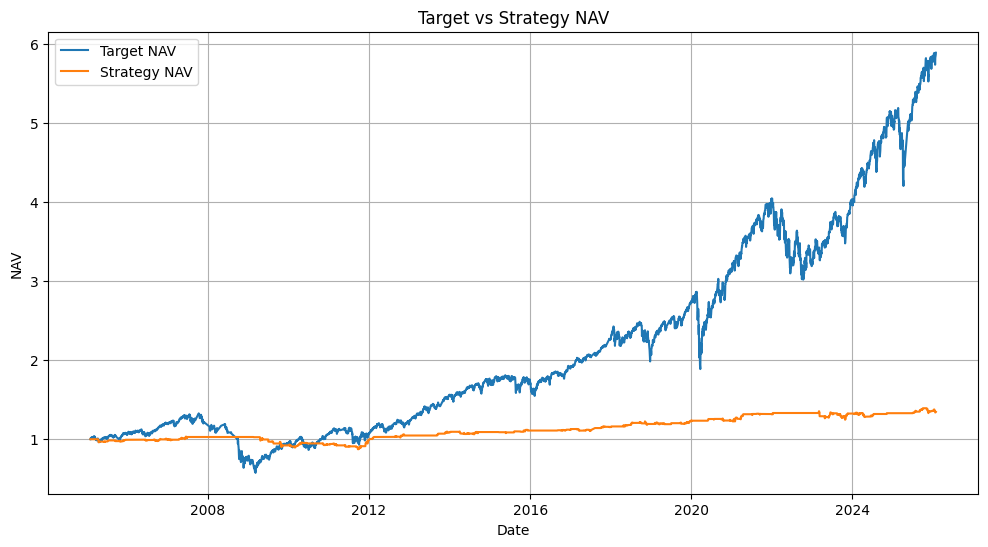

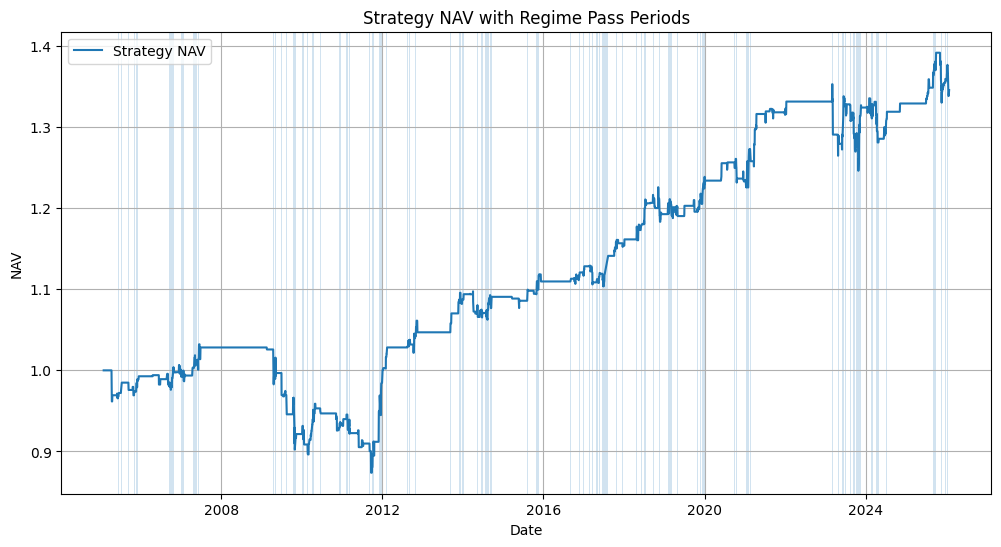

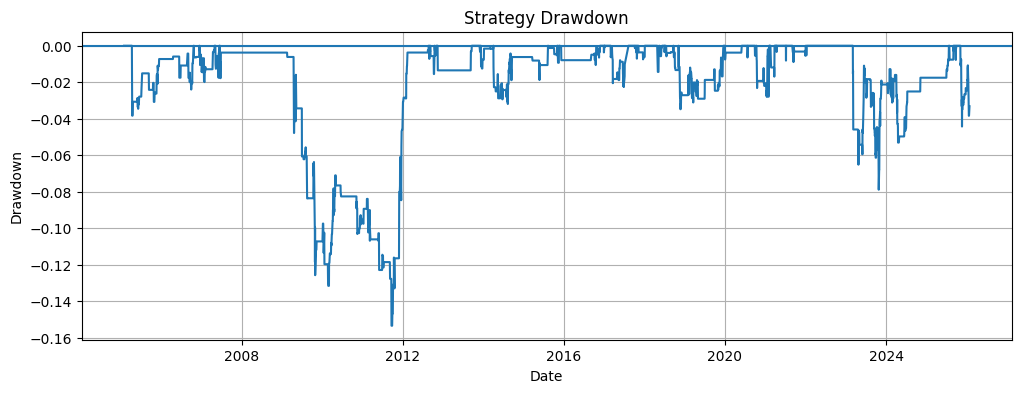

📉 Max Drawdown: -15.34%
✅ [셀 7] 시각화 완료


In [12]:
# =========================================
# [셀 7] Carry Trade Regime Engine - 시각화 (NAV / Regime / Drawdown)
#
# 목적:
# - 레짐 기반 전략이 언제 작동했는지 시각적으로 검증
#
# 구성:
# (1) 타겟 NAV vs 전략 NAV
# (2) 전략 NAV + REGIME Pass 구간 음영
# (3) 전략 Drawdown
#
# 주의:
# - matplotlib only
# - 색상 지정 안 함
# =========================================

import matplotlib.pyplot as plt
import numpy as np


# -----------------------------------------
# 1) 데이터 준비
# -----------------------------------------
plot_df = df_sig.copy()

required_cols = [
    "target_nav",
    "strategy_nav",
    "REGIME__pass",
    "strategy_ret_1d",
]
for c in required_cols:
    if c not in plot_df.columns:
        raise KeyError(f"시각화에 필요한 컬럼이 없소: {c}")

dates = plot_df.index


# -----------------------------------------
# 2) (그래프 1) 타겟 NAV vs 전략 NAV    목표는 타겟 NAV 떡락할 때 전략이 안떡락하면 됨 ㅇㅇ; 전략은 원래 낮아 여기서
# -----------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(dates, plot_df["target_nav"], label="Target NAV")
plt.plot(dates, plot_df["strategy_nav"], label="Strategy NAV")
plt.legend()
plt.title("Target vs Strategy NAV")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()


# -----------------------------------------
# 3) (그래프 2) 전략 NAV + Regime Pass 음영                  PASS일때 돈 벌었냐 이거지
# -----------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(dates, plot_df["strategy_nav"], label="Strategy NAV")

in_pass = plot_df["REGIME__pass"].fillna(False)

start = None
for i in range(len(in_pass)):
    if in_pass.iloc[i] and start is None:
        start = dates[i]
    if (not in_pass.iloc[i] or i == len(in_pass) - 1) and start is not None:
        end = dates[i]
        plt.axvspan(start, end, alpha=0.2)
        start = None

plt.legend()
plt.title("Strategy NAV with Regime Pass Periods")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()


# -----------------------------------------
# 4) (그래프 3) 전략 Drawdown               최대 낙폭이 -15%정도인데, SPY의 낙폭은 원래 -50%정도됨 ㅇㅇ
# 다만 아쉬운 점은 Drawdown 이 0이 되는 구간이 많은데= 레짐이 자주 켜졌다 꺼졌다 하는거임
# -----------------------------------------
nav = plot_df["strategy_nav"].ffill()   # 🔧 수정 포인트
rolling_max = nav.cummax()
drawdown = nav / rolling_max - 1.0

plt.figure(figsize=(12, 4))
plt.plot(dates, drawdown, label="Drawdown")
plt.axhline(0.0)
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()


# -----------------------------------------
# 5) Drawdown 요약
# -----------------------------------------
max_dd = float(drawdown.min())
print(f"📉 Max Drawdown: {max_dd:.2%}")

print("✅ [셀 7] 시각화 완료")


In [13]:
# =========================================
# [셀 8] Carry Trade Regime Engine - 검증(레짐 Pass vs Fail 성과 비교)
#
# 목적:
# - REGIME__pass(True/False)가 타겟 수익률/리스크를 실제로 분리하는지 검증
#
# 출력:
# (1) Pass/Faill 구간별 평균수익, 변동성, 샤프(단순), 승률
# (2) Pass/Faill 구간별 최대낙폭(타겟 기준, 전략 기준)
# (3) (선택) 다음 5/20일 forward return 차이(예측력 느낌 확인)
#
# 주의:
# - proxy 지표를 쓴 상태라 "정밀 검증"이 아니라 "구조 검증"임
# - 룩어헤드 방지: signal은 이미 shift(1) 적용되어 있음
# =========================================

import numpy as np
import pandas as pd


# -----------------------------------------
# 1) 준비: 필요한 컬럼 체크
# -----------------------------------------
need = ["REGIME__pass", "target_ret_1d", "strategy_ret_1d", "target_nav", "strategy_nav"]
for c in need:
    if c not in df_sig.columns:
        raise KeyError(f"df_sig에 필요한 컬럼이 없소: {c}")

test_df = df_sig.copy().dropna(subset=["REGIME__pass", "target_ret_1d", "strategy_ret_1d"])


# -----------------------------------------
# 2) 함수: 성과 요약
# -----------------------------------------
def _perf_stats(ret: pd.Series) -> dict:
    ret = ret.dropna()
    if ret.empty:
        return dict(mean=np.nan, vol=np.nan, sharpe=np.nan, winrate=np.nan, n=0)

    mu = float(ret.mean())
    sd = float(ret.std(ddof=0))
    sharpe = (mu / sd * np.sqrt(252)) if (sd and not np.isnan(sd)) else np.nan
    winrate = float((ret > 0).mean())
    return dict(mean=mu, vol=sd, sharpe=sharpe, winrate=winrate, n=int(ret.shape[0]))


def _max_drawdown_from_nav(nav: pd.Series) -> float:
    nav = nav.dropna()
    if nav.empty:
        return np.nan
    peak = nav.cummax()
    dd = nav / peak - 1.0
    return float(dd.min())


# -----------------------------------------
# 3) Pass vs Fail 구간 분리
# -----------------------------------------
pass_mask = test_df["REGIME__pass"] == True
fail_mask = test_df["REGIME__pass"] == False

# 타겟/전략의 일간 수익률 비교
stats = []

for label, m in [("PASS", pass_mask), ("FAIL", fail_mask)]:
    s_target = _perf_stats(test_df.loc[m, "target_ret_1d"])
    s_strat  = _perf_stats(test_df.loc[m, "strategy_ret_1d"])

    # 구간별 NAV 최대낙폭(해당 구간만 잘라서 계산)
    # 주의: 구간을 '잘라' 계산하므로, "구간 내부" 낙폭을 보는 용도임
    dd_target = _max_drawdown_from_nav(test_df.loc[m, "target_nav"])
    dd_strat  = _max_drawdown_from_nav(test_df.loc[m, "strategy_nav"])

    stats.append({
        "regime": label,
        "n_days": s_target["n"],
        "target_mean_1d": s_target["mean"],
        "target_vol_1d": s_target["vol"],
        "target_sharpe": s_target["sharpe"],
        "target_winrate": s_target["winrate"],
        "target_maxdd_in_regime": dd_target,
        "strategy_mean_1d": s_strat["mean"],
        "strategy_vol_1d": s_strat["vol"],
        "strategy_sharpe": s_strat["sharpe"],
        "strategy_winrate": s_strat["winrate"],
        "strategy_maxdd_in_regime": dd_strat,
    })

stats_df = pd.DataFrame(stats)
display(stats_df)


# -----------------------------------------
# 4) 예측력 느낌 확인: Forward Return (5일, 20일)
# -----------------------------------------
# "오늘 레짐이 PASS면, 앞으로 n일 수익률이 상대적으로 낫나?"
# (단, 레짐 신호는 이미 오늘 정보로 판정된 것이므로, 여기서 forward는 의미가 있음)
for horizon in [5, 20]:
    test_df[f"target_fwd_{horizon}d"] = (1.0 + test_df["target_ret_1d"]).rolling(horizon).apply(np.prod, raw=True) - 1.0
    test_df[f"target_fwd_{horizon}d"] = test_df[f"target_fwd_{horizon}d"].shift(-horizon)

fwd_rows = []
for horizon in [5, 20]:
    p = test_df.loc[pass_mask, f"target_fwd_{horizon}d"].dropna()
    f = test_df.loc[fail_mask, f"target_fwd_{horizon}d"].dropna()
    fwd_rows.append({
        "horizon_days": horizon,
        "PASS_mean_fwd": float(p.mean()) if len(p) else np.nan,
        "FAIL_mean_fwd": float(f.mean()) if len(f) else np.nan,
        "PASS_minus_FAIL": (float(p.mean()) - float(f.mean())) if (len(p) and len(f)) else np.nan,
        "PASS_n": int(len(p)),
        "FAIL_n": int(len(f)),
    })

fwd_df = pd.DataFrame(fwd_rows)
display(fwd_df)

print("✅ [셀 8] 검증 완료 — PASS가 FAIL보다 '수익↑/낙폭↓'이면 레짐 필터로 의미가 있소.")


,regime,n_days,target_mean_1d,target_vol_1d,target_sharpe,target_winrate,target_maxdd_in_regime,strategy_mean_1d,strategy_vol_1d,strategy_sharpe,strategy_winrate,strategy_maxdd_in_regime
0,PASS,736,0.001081,0.007806,2.197876,0.586957,-0.485852,0.000248,0.004951,0.793649,0.267663,-0.153398
1,FAIL,4247,0.000320,0.013007,0.390509,0.539675,-0.564737,0.000032,0.002355,0.214877,0.051095,-0.153398


,horizon_days,PASS_mean_fwd,FAIL_mean_fwd,PASS_minus_FAIL,PASS_n,FAIL_n
0,5,0.001819,0.002119,-0.000300,734,4244
1,20,0.010868,0.007743,0.003125,725,4238


✅ [셀 8] 검증 완료 — PASS가 FAIL보다 '수익↑/낙폭↓'이면 레짐 필터로 의미가 있소.


In [ ]:
# =========================================
# [셀 9] Carry Trade Regime Engine - 설계 논리 정리 (검토용 문서 셀)
#
# 이 셀은 "왜 이 레짐 모델이 이렇게 구성되었는지"를 설명하기 위한 문서 셀이다.
# 실행 목적은 없으며, 이후 모델 개선/확장 시 기준점(anchor)으로 사용한다.
#
# -------------------------------------------------
# 0. 전체 구조 요약
#
# 이 모델은 다음 4단계 구조를 따른다.
#
# (1) Raw Indicator (서로 단위가 다른 지표들)
# (2) Normalized Score (0~100, 비교 가능)
# (3) Indicator Pass / Fail (+ Hard Fail)
# (4) Weighted Regime Score → 최종 Regime Pass / Fail
#
# 핵심 질문:
#   "지금은 캐리 트레이드가 구조적으로 살아 있는 환경인가?"
#
# -------------------------------------------------
# 1. 지표 점수(score)는 어떻게 산출되었는가
#
# 지표들은 성격에 따라 두 가지 방식으로 정규화된다.
#
# [A] Percentile Rank 방식 (레벨 자체가 중요한 지표)
#   - 대상: VIX, FX Implied Vol (proxy)
#   - 방법:
#       * 과거 252영업일 내에서 현재 값의 분위(percentile) 계산
#       * 변동성은 낮을수록 좋으므로 score = (1 - percentile) * 100
#   - 해석:
#       * 절대 수준이 아니라 "과거 대비 환경"을 측정
#
# [B] Z-score 방식 (방향성과 이례성이 중요한 지표)
#   - 대상: USDJPY 모멘텀, Carry-to-Risk, Funding Basis, Risk Reversal
#   - 방법:
#       * rolling mean / std로 z-score 계산
#       * 극단값 방지를 위해 z-score를 ±z_cap으로 clip
#       * 이를 0~100 점수로 선형 변환
#   - 해석:
#       * 해당 지표가 자기 역사 대비 얼마나 유리한 방향에 있는가
#
# -------------------------------------------------
# 2. 지표별 Pass / Fail 기준은 어떻게 설정되었는가
#
# 중요:
#   - 이 기준들은 백테스트 최적화 결과가 아님
#   - 경제적 구조에 기반한 "보수적 휴리스틱"임
#
# [VIX]
#   - Pass 기준: score >= 55
#   - 논리:
#       * 캐리는 저변동성 환경에서만 안정적으로 작동
#
# [USDJPY 모멘텀] (Hard Fail)
#   - Pass 기준: score >= 45
#   - Hard Fail = True
#   - 논리:
#       * 엔 강세(USDJPY 하락)는 캐리 청산의 대표적 신호
#
# [FX Implied Vol] (Hard Fail)
#   - Pass 기준: score >= 55
#   - 논리:
#       * 캐리는 변동성 프리미엄 전략
#       * 변동성 급등은 구조적 붕괴 신호
#
# [Carry-to-Risk]
#   - Pass 기준: score >= 50
#   - 논리:
#       * 수익 대비 리스크가 평균 이상인지 확인하는 보조 지표
#
# [USD Funding Basis] (Hard Fail)
#   - Pass 기준: score >= 45
#   - 논리:
#       * 달러 펀딩 스트레스는 글로벌 레버리지 축소 신호
#
# [FX Risk Reversal]
#   - Pass 기준: score >= 45
#   - 논리:
#       * 옵션 시장의 꼬리 리스크 인식(심리/포지셔닝)
#       * 보조 지표로 낮은 가중치 부여
#
# -------------------------------------------------
# 3. Regime Score는 어떻게 합산되는가
#
# Regime Score는 단순 평균이 아니라 "가중 평균"이다.
#
#   REGIME__score
#   = Σ(지표 score × weight) / Σ(weight)
#
# 가중치 설계 원칙:
#   - FX IV, USDJPY, Funding Basis → 구조적 위험 → 높은 가중치
#   - Risk Reversal → 심리 보조 → 낮은 가중치
#
# 의미:
#   - 다수결이 아니라 "위험의 무게 중심"을 반영한 점수
#
# -------------------------------------------------
# 4. 최종 Regime Pass / Fail 결정 구조
#
# 결정 로직은 2단계다.
#
# (1) Hard Fail 체크
#     - Hard Fail 지표 중 하나라도 Fail이면
#       → 전체 Regime = FAIL
#
# (2) Hard Fail이 없을 경우
#     - REGIME__score >= final_pass_score_thresh (현재 60)
#       → Regime = PASS
#     - 아니면 FAIL
#
# 이 구조로 인해:
#   - PASS 비율은 약 15%로 낮음
#   - 모델은 의도적으로 매우 보수적
#
# -------------------------------------------------
# 5. 현재 설계의 성격에 대한 평가
#
# 장점:
#   - 캐리 붕괴 레짐을 구조적으로 포착
#   - 해석 가능성 높음
#   - 리스크 관리 필터로 기능함
#
# 한계:
#   - 임계값(45, 55, 60)은 경험적
#   - 0/1 구조로 정보 손실 발생
#   - Hard Fail이 강해 기회 손실 존재
#
# 결론:
#   - "틀린 모델"이 아니라
#   - "지나치게 보수적인 레짐 필터"
#
# 이후 개선 방향:
#   - Pass/Fail → 연속 점수 기반 포지션
#   - Hard Fail → Soft Penalty
#   - 캐리 민감도가 높은 타겟 자산 적용
#
# =========================================
